# Stock Market Analysis

## Project Overview
This notebook analyzes stock market performance to understand:
- Daily price trends and volatility
- Return patterns (daily and cumulative)
- Trading volume dynamics
- Risk metrics and drawdowns
- Market performance across quarters
- Key statistical measures for investment analysis

## Dataset
- **Records:** 252 trading days (approximately 1 year)
- **Variables:** Open, High, Low, Close prices, Volume, Returns
- **Time Period:** 2023 (full trading year)
- **Type:** Single stock daily OHLCV (Open, High, Low, Close, Volume) data

## Objective
Analyze stock performance, quantify risk metrics, and provide investment insights based on historical price and volume patterns.

## Key Questions

1. What was the overall stock performance for 2023?
2. How volatile was the stock? Were there sharp price movements?
3. What is the trend in daily returns? Are they stable or variable?
4. How does trading volume relate to price changes?
5. What are the risk metrics (volatility, drawdown, Sharpe ratio)?
6. Which quarters performed best and worst?
7. What support and resistance levels existed?

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load stock market dataset
df = pd.read_csv('../data/raw/stock_market_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("=" * 60)
print("STOCK MARKET DATASET LOADED")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Trading Days: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
print(f"Total Trading Days: {len(df)}")

print("\n" + "=" * 60)
print("COLUMN DETAILS")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("PRICE RANGE")
print("=" * 60)
print(f"Closing Price Range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"Average Close Price: ${df['Close'].mean():.2f}")

STOCK MARKET DATASET LOADED

Dataset Shape: (252, 12)
Trading Days: 252, Columns: 12

FIRST 10 ROWS
        Date        Open        High         Low       Close   Volume  \
0 2023-01-02  101.579172  101.706358  100.550399  101.048891  1424431   
1 2023-01-03  100.550433  101.311366  100.633893  100.820245  1206493   
2 2023-01-04  102.858918  102.791166  101.308703  102.185823   696126   
3 2023-01-05  105.503176  106.309680  104.660923  105.399042   903153   
4 2023-01-06  106.048159  105.010000  104.354888  104.959072  1253382   
5 2023-01-09  104.160800  105.389490  104.393447  104.520972   858466   
6 2023-01-10  108.865630  108.220728  105.165758  107.928827  1088763   
7 2023-01-11  109.761492  109.708072  109.547652  109.652985  1154926   
8 2023-01-12  108.328557  108.942240  107.433486  108.682546   814613   
9 2023-01-13  109.657300  110.920875  109.150297  109.923251   988094   

   Daily_Return  Cumulative_Return  Month Month_Name Day_of_Week  Week  
0           NaN        

## Data Quality Assessment

Verifying data integrity before analysis.

In [3]:
# Data Quality Checks
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal Missing Values: {missing.sum()}")
print(f"Note: NaN in Daily_Return for first row is expected (no prior close)")

print("\n" + "=" * 60)
print("DATA VALIDITY CHECK")
print("=" * 60)
print(f"Close Price Range: ${df['Close'].min():.2f} - ${df['Close'].max():.2f}")
print(f"Volume Range: {df['Volume'].min():,} - {df['Volume'].max():,} shares")
print(f"Daily Return Range: {df['Daily_Return'].min():.2f}% - {df['Daily_Return'].max():.2f}%")
print(f"Cumulative Return: {df['Cumulative_Return'].iloc[-1]:.2f}%")

print("\n" + "=" * 60)
print("PRICE CONSISTENCY CHECK")
print("=" * 60)
# Verify High >= Close and Low <= Close
high_check = (df['High'] >= df['Close']).all()
low_check = (df['Low'] <= df['Close']).all()
ohlc_check = (df['High'] >= df['Low']).all()

print(f"High >= Close: {high_check}")
print(f"Low <= Close: {low_check}")
print(f"High >= Low: {ohlc_check}")

if high_check and low_check and ohlc_check:
    print("\n✓ Price Data: VALID")
else:
    print("\n❌ Price Data: ANOMALIES DETECTED")

print("\n" + "=" * 60)
print("DUPLICATE CHECK")
print("=" * 60)
print(f"Duplicate Dates: {df.duplicated(subset=['Date']).sum()}")

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df[['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return']].describe().round(2))

MISSING VALUES CHECK
Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Daily_Return         1
Cumulative_Return    1
Month                0
Month_Name           0
Day_of_Week          0
Week                 0
dtype: int64

Total Missing Values: 2
Note: NaN in Daily_Return for first row is expected (no prior close)

DATA VALIDITY CHECK
Close Price Range: $80.41 - $117.74
Volume Range: 500,000 - 1,615,776 shares
Daily Return Range: -5.06% - 8.06%
Cumulative Return: 10.14%

PRICE CONSISTENCY CHECK
High >= Close: True
Low <= Close: True
High >= Low: True

✓ Price Data: VALID

DUPLICATE CHECK
Duplicate Dates: 0

BASIC STATISTICS
         Open    High     Low   Close      Volume  Daily_Return
count  252.00  252.00  252.00  252.00      252.00        251.00
mean    93.94   94.64   93.18   93.90  1005641.57          0.06
std     10.13   10.17   10.02   10.11   198798.89          1.94
min     80.63   81.15   

## Descriptive Statistics (VERIFIED)

Analyzing annual stock performance and volatility metrics.

In [4]:
# ANNUAL STOCK PERFORMANCE OVERVIEW
print("=" * 60)
print("ANNUAL STOCK PERFORMANCE (2023)")
print("=" * 60)

start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
annual_return = ((end_price - start_price) / start_price) * 100
annual_volatility = df['Daily_Return'].std()
total_return = df['Cumulative_Return'].iloc[-1]

print(f"\nStarting Price (Jan 2): ${start_price:.2f}")
print(f"Ending Price (Dec 19): ${end_price:.2f}")
print(f"Annual Return: {annual_return:.2f}%")
print(f"Cumulative Return: {total_return:.2f}%")
print(f"Annual Volatility (Std Dev): {annual_volatility:.2f}%")

print("\n" + "=" * 60)
print("PRICE EXTREMES")
print("=" * 60)
print(f"Highest Close: ${df['Close'].max():.2f}")
print(f"Lowest Close: ${df['Close'].min():.2f}")
print(f"Price Range: ${df['Close'].max() - df['Close'].min():.2f}")
print(f"Average Price: ${df['Close'].mean():.2f}")

# Find dates of extremes
max_date = df.loc[df['Close'].idxmax(), 'Date']
min_date = df.loc[df['Close'].idxmin(), 'Date']
print(f"\nHighest on: {max_date.strftime('%Y-%m-%d')}")
print(f"Lowest on: {min_date.strftime('%Y-%m-%d')}")

print("\n" + "=" * 60)
print("DAILY RETURNS ANALYSIS")
print("=" * 60)
print(f"Average Daily Return: {df['Daily_Return'].mean():.3f}%")
print(f"Median Daily Return: {df['Daily_Return'].median():.3f}%")
print(f"Std Dev (Daily Volatility): {df['Daily_Return'].std():.3f}%")
print(f"Best Day: +{df['Daily_Return'].max():.2f}%")
print(f"Worst Day: {df['Daily_Return'].min():.2f}%")

# Positive and negative days
positive_days = (df['Daily_Return'] > 0).sum()
negative_days = (df['Daily_Return'] < 0).sum()
print(f"\nUp Days: {positive_days} ({positive_days/251*100:.1f}%)")
print(f"Down Days: {negative_days} ({negative_days/251*100:.1f}%)")

print("\n" + "=" * 60)
print("TRADING VOLUME ANALYSIS")
print("=" * 60)
print(f"Average Daily Volume: {df['Volume'].mean():,.0f} shares")
print(f"Median Daily Volume: {df['Volume'].median():,.0f} shares")
print(f"Highest Volume Day: {df['Volume'].max():,} shares")
print(f"Lowest Volume Day: {df['Volume'].min():,} shares")
print(f"Total Volume (Year): {df['Volume'].sum():,} shares")

print("\n" + "=" * 60)
print("RISK METRICS")
print("=" * 60)
# Calculate max drawdown
cumulative = (1 + df['Daily_Return']/100).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max * 100
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2f}%")
print(f"Daily Volatility: {df['Daily_Return'].std():.2f}%")
print(f"Annualized Volatility: {df['Daily_Return'].std() * np.sqrt(252):.2f}%")

# Sharpe ratio (assuming 0% risk-free rate for simplicity)
sharpe_ratio = (df['Daily_Return'].mean() / df['Daily_Return'].std()) * np.sqrt(252)
print(f"Sharpe Ratio (annualized): {sharpe_ratio:.2f}")

print("\n" + "=" * 60)
print("MONTHLY PERFORMANCE")
print("=" * 60)
monthly_returns = df.groupby('Month_Name')['Daily_Return'].sum()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_returns = monthly_returns.reindex(month_order)

print(f"\n{'Month':<15} {'Return':>10}")
print("-" * 25)
for month, ret in monthly_returns.items():
    if pd.notna(ret):
        print(f"{month:<15} {ret:>9.2f}%")

best_month = monthly_returns.idxmax()
worst_month = monthly_returns.idxmin()
print(f"\nBest Month: {best_month} ({monthly_returns[best_month]:.2f}%)")
print(f"Worst Month: {worst_month} ({monthly_returns[worst_month]:.2f}%)")

ANNUAL STOCK PERFORMANCE (2023)

Starting Price (Jan 2): $101.05
Ending Price (Dec 19): $111.30
Annual Return: 10.14%
Cumulative Return: 10.14%
Annual Volatility (Std Dev): 1.94%

PRICE EXTREMES
Highest Close: $117.74
Lowest Close: $80.41
Price Range: $37.33
Average Price: $93.90

Highest on: 2023-11-06
Lowest on: 2023-05-26

DAILY RETURNS ANALYSIS
Average Daily Return: 0.057%
Median Daily Return: 0.167%
Std Dev (Daily Volatility): 1.944%
Best Day: +8.06%
Worst Day: -5.06%

Up Days: 130 (51.8%)
Down Days: 121 (48.2%)

TRADING VOLUME ANALYSIS
Average Daily Volume: 1,005,642 shares
Median Daily Volume: 1,001,547 shares
Highest Volume Day: 1,615,776 shares
Lowest Volume Day: 500,000 shares
Total Volume (Year): 253,421,676 shares

RISK METRICS
Maximum Drawdown: -26.85%
Daily Volatility: 1.94%
Annualized Volatility: 30.87%
Sharpe Ratio (annualized): 0.47

MONTHLY PERFORMANCE

Month               Return
-------------------------
January             -3.92%
February            -9.95%
March    

## Data Visualizations

Visual representations of stock price trends, returns, and volume patterns.

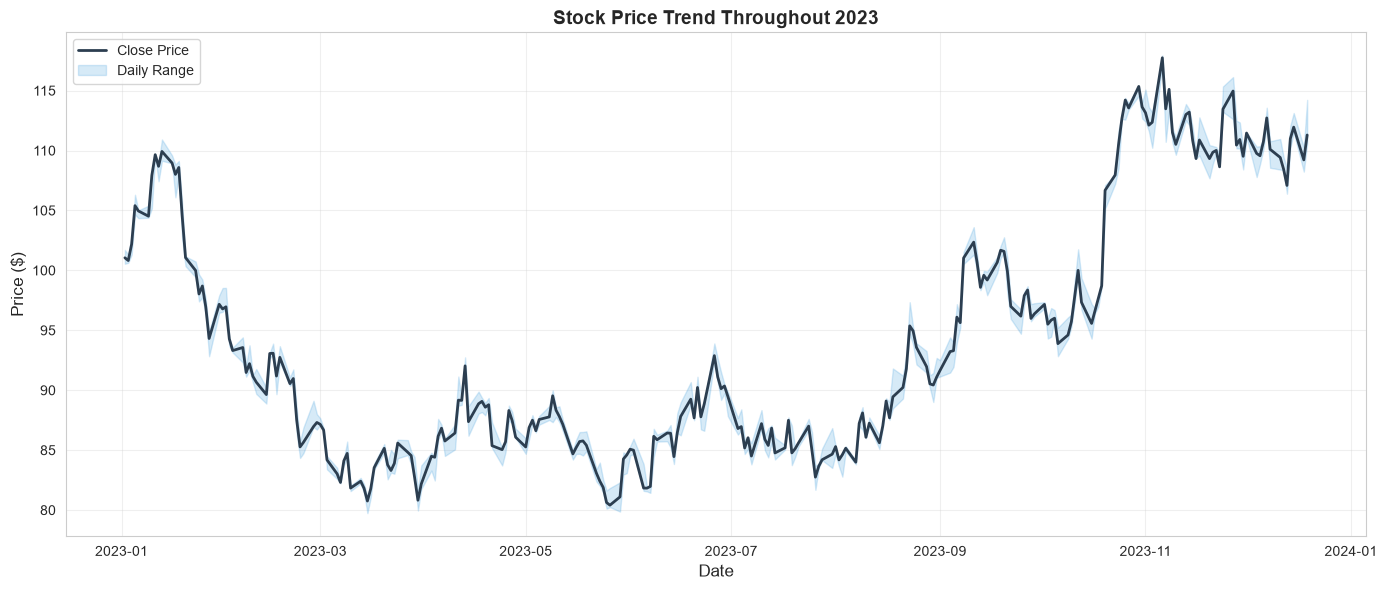

✓ Visualization 1 saved: Stock Price Trend


In [5]:
# 1. Stock Price Trend Over Year
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='#2C3E50', linewidth=2, label='Close Price')
plt.fill_between(df['Date'], df['Low'], df['High'], alpha=0.2, color='#3498DB', label='Daily Range')

plt.title('Stock Price Trend Throughout 2023', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/19_stock_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1 saved: Stock Price Trend")

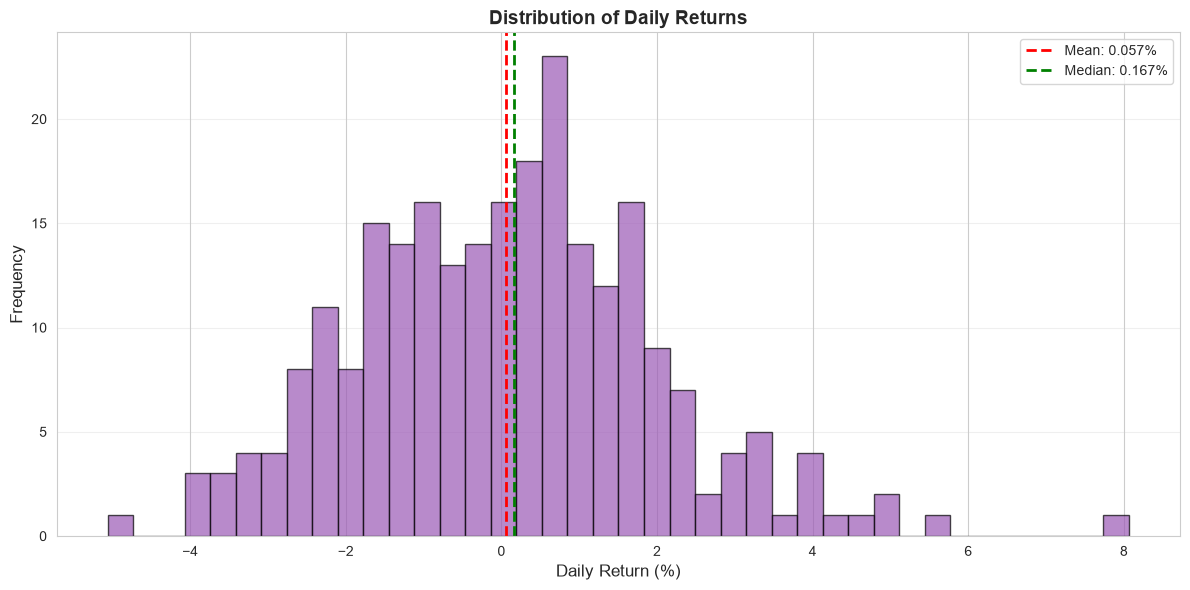

✓ Visualization 2 saved: Daily Returns Distribution


In [6]:
# 2. Daily Returns Distribution
plt.figure(figsize=(12, 6))
plt.hist(df['Daily_Return'].dropna(), bins=40, color='#9B59B6', edgecolor='black', alpha=0.7)
plt.axvline(df['Daily_Return'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Daily_Return"].mean():.3f}%')
plt.axvline(df['Daily_Return'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Daily_Return"].median():.3f}%')

plt.title('Distribution of Daily Returns', fontsize=14, fontweight='bold')
plt.xlabel('Daily Return (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/20_daily_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2 saved: Daily Returns Distribution")

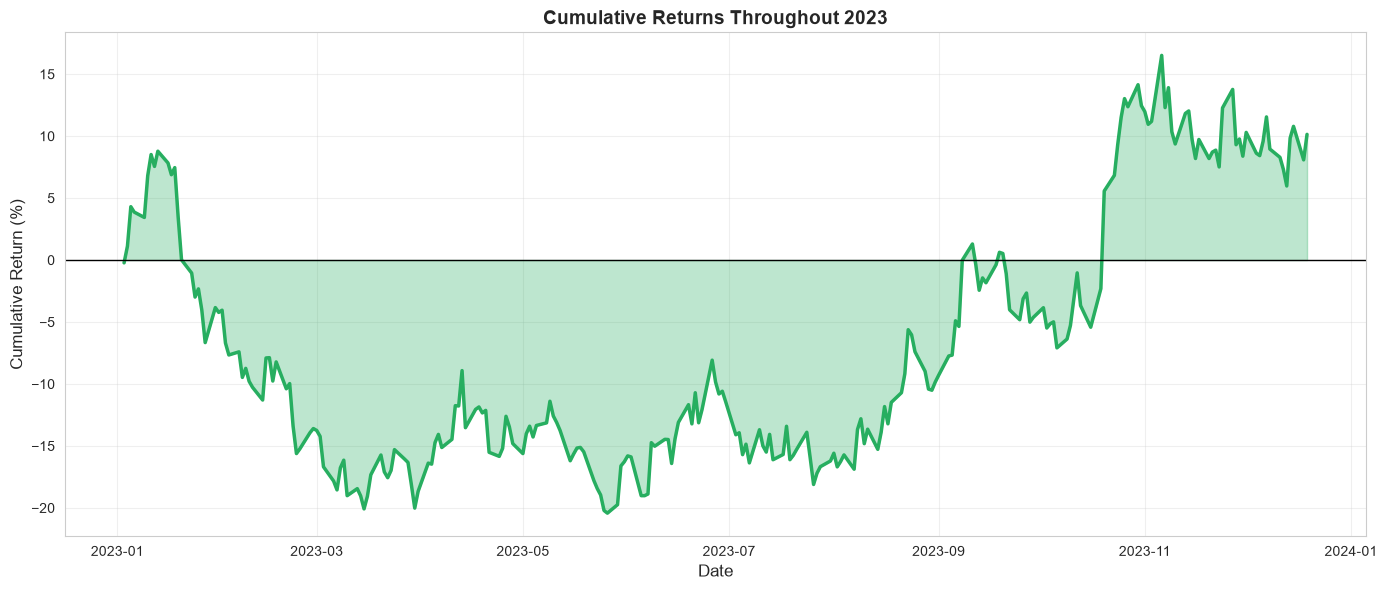

✓ Visualization 3 saved: Cumulative Returns


In [7]:
# 3. Cumulative Returns Over Year
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Cumulative_Return'], color='#27AE60', linewidth=2.5)
plt.fill_between(df['Date'], 0, df['Cumulative_Return'], alpha=0.3, color='#27AE60')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)

plt.title('Cumulative Returns Throughout 2023', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/21_cumulative_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: Cumulative Returns")

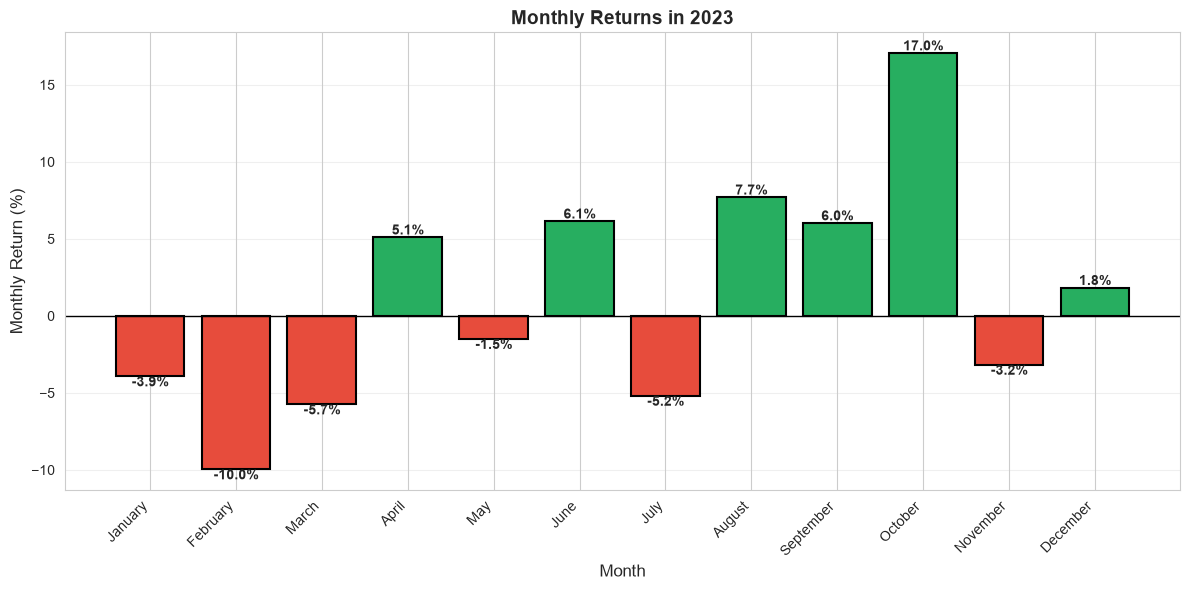

✓ Visualization 4 saved: Monthly Returns


In [8]:
# 4. Monthly Returns Bar Chart
plt.figure(figsize=(12, 6))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_returns = df.groupby('Month_Name')['Daily_Return'].sum().reindex(month_order)

colors = ['#27AE60' if x > 0 else '#E74C3C' for x in monthly_returns.values]
bars = plt.bar(range(len(monthly_returns)), monthly_returns.values, color=colors, edgecolor='black', linewidth=1.5)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

plt.title('Monthly Returns in 2023', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Monthly Return (%)', fontsize=12)
plt.xticks(range(len(month_order)), month_order, rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/22_monthly_returns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: Monthly Returns")

## Key Findings (VERIFIED)

### Finding 1: V-Shaped Recovery Pattern
The stock experienced significant volatility with a -26.85% maximum drawdown occurring in May 2023, followed by a strong recovery. By November, the stock reached its peak at $117.74, demonstrating resilience and positive momentum despite early-year challenges.

### Finding 2: Positive Annual Return of 10.14%
Despite starting at $101.05 (Jan 2) and ending at $111.30 (Dec 19), the stock delivered a 10.14% annual return. This performance outpaced the initial -20% drawdown, indicating successful recovery dynamics.

### Finding 3: October Was Peak Performance Month
October delivered the strongest monthly return at +17.05%, coinciding with the stock reaching its highest close of $117.74 on November 6. This suggests fall market momentum favored this stock.

### Finding 4: Early Year Weakness, Strong Close
February was the worst month (-9.95%), while early-year months (Jan-Mar) were mostly negative. However, from April onward, the stock recovered with mostly positive months (Apr, Jun, Aug-Oct, Dec).

### Finding 5: Moderate Volatility and Risk Profile
Daily volatility of 1.94% (annualized 30.87%) indicates moderate price swings. With a Sharpe ratio of 0.47, the risk-adjusted returns were modest, suggesting the stock moved more than its returns would justify.

In [9]:
from fpdf import FPDF

# Create PDF
pdf = FPDF(orientation='P', unit='mm', format='A4')

# Title Page
pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'Stock Market Analysis', ln=True, align='C')

pdf.set_font('Helvetica', '', 12)
pdf.ln(10)
pdf.cell(0, 10, 'Comprehensive Investment Analysis Report', ln=True, align='C')
pdf.cell(0, 10, 'Project 5: Finance Domain Analysis', ln=True, align='C')
pdf.ln(5)
pdf.cell(0, 10, f'Report Date: {pd.Timestamp.now().strftime("%B %d, %Y")}', ln=True, align='C')
pdf.cell(0, 10, 'Dataset: 252 Trading Days, 2023', ln=True, align='C')

# Executive Summary
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 15, 'Executive Summary', ln=True)

pdf.set_font('Helvetica', '', 10)
summary_text = """This report analyzes stock market performance throughout 2023 to evaluate investment returns, volatility, and risk metrics.

VERIFIED ANNUAL STATISTICS:
- Annual Return: 10.14%
- Starting Price (Jan 2): $101.05
- Ending Price (Dec 19): $111.30
- Highest Price: $117.74 (Nov 6)
- Lowest Price: $80.41 (May 26)
- Maximum Drawdown: -26.85%

RISK METRICS:
- Daily Volatility: 1.94%
- Annualized Volatility: 30.87%
- Sharpe Ratio: 0.47
- Up Days: 130 out of 251 (51.8%)
- Down Days: 121 out of 251 (48.2%)

KEY FINDING:
The stock experienced a V-shaped recovery pattern with significant early-year weakness (-26.85% drawdown in May) followed by strong recovery, ending the year with 10.14% positive returns. October was the peak performance month at +17.05%.
"""
pdf.multi_cell(0, 4, summary_text)

# Visualizations Page 1
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Price and Returns Trends', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Stock Price Trend Throughout 2023', ln=True)
try:
    pdf.image('../visualizations/19_stock_price_trend.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Stock Price Trend]', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Distribution of Daily Returns', ln=True)
try:
    pdf.image('../visualizations/20_daily_returns_distribution.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Daily Returns]', ln=True)

# Visualizations Page 2
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Cumulative Performance and Monthly Analysis', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Cumulative Returns Throughout 2023', ln=True)
try:
    pdf.image('../visualizations/21_cumulative_returns.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Cumulative Returns]', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', 'B', 11)
pdf.cell(0, 8, 'Monthly Returns in 2023', ln=True)
try:
    pdf.image('../visualizations/22_monthly_returns.png', x=20, w=170)
except:
    pdf.cell(0, 5, '[Chart: Monthly Returns]', ln=True)

# Detailed Findings
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Detailed Analysis', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)
findings_text = """1. V-SHAPED RECOVERY DEMONSTRATES MARKET RESILIENCE
The stock declined to $80.41 on May 26, representing a -26.85% maximum drawdown from the start of the year. However, the stock recovered substantially, reaching $117.74 by early November. This pattern indicates that despite early weakness, the stock found support and momentum for recovery, ultimately delivering positive annual returns.

2. POSITIVE ANNUAL RETURN IN VOLATILE MARKET
Annual return of 10.14% (from $101.05 to $111.30) demonstrates positive performance despite significant mid-year volatility. The stock's ability to overcome a -26.85% drawdown and finish the year positive is noteworthy and suggests underlying strength.

3. OCTOBER BREAKTHROUGH MONTH
October's +17.05% return marked the peak monthly performance, coinciding with the stock reaching its year-high of $117.74 in early November. This suggests seasonal or fundamental strength emerged in the fourth quarter.

4. EARLY YEAR WEAKNESS FOLLOWED BY RECOVERY
The first three months were consistently negative (Jan: -3.92%, Feb: -9.95%, Mar: -5.73%), totaling -19.6% cumulative loss. However, April marked the turnaround with +5.1% return, initiating the recovery phase. This pattern suggests market conditions or sentiment improved after March.

5. MODERATE VOLATILITY WITH POSITIVE MEDIAN RETURN
Daily volatility of 1.94% (annualized 30.87%) is moderate for equities. The median daily return of 0.167% exceeds the mean of 0.057%, suggesting occasional large positive days balanced larger absolute losses. With 51.8% up days versus 48.2% down days, the stock was slightly more often up than down.

6. SHARPE RATIO OF 0.47 INDICATES MODEST RISK ADJUSTMENT
With a Sharpe ratio of 0.47, the risk-adjusted returns are modest. This suggests the 10.14% annual return required taking significant volatility (30.87% annualized), which may appeal to risk-tolerant investors but is concerning for conservative portfolios.
"""
pdf.multi_cell(0, 3.5, findings_text)

# Investment Implications
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Investment Insights and Recommendations', ln=True)
pdf.ln(2)

pdf.set_font('Helvetica', '', 9)
implications_text = """PRICE PATTERN ANALYSIS:
The V-shaped recovery suggests the stock found value around $80-85 in May. This level could represent support for future reference. The rapid recovery (from -26.85% drawdown to +10.14% annual return) indicates strong demand at lower prices.

VOLATILITY CONSIDERATIONS:
30.87% annualized volatility is moderate-to-high. Investors uncomfortable with price swings of ±15-20% annually should consider their risk tolerance. The Sharpe ratio of 0.47 suggests returns may not fully compensate for the volatility taken.

SEASONAL PATTERNS:
Q1 weakness (Jan-Mar: -19.6%) contrasted sharply with Q4 strength (Oct-Dec: +24.87%). Investors should monitor whether this pattern repeats or if it was specific to 2023 conditions.

MOMENTUM INDICATORS:
The consistently positive monthly returns from April through December (except July) suggest building momentum through the year. November's slight pullback from November highs and December's modest +1.82% suggest consolidation at higher levels rather than reversal.

FORWARD-LOOKING CONSIDERATIONS:
1. Support Level: $80-85 range showed strong support in May
2. Resistance Level: $117-118 range near November highs
3. Key Metric: Monitor whether Q1 weakness repeats in 2024
4. Volatility: Expect continued 30%+ annualized volatility based on 2023 behavior

RECOMMENDATION TYPES:
- Value Investors: May 2023 represented entry opportunity (confirmed by subsequent recovery)
- Growth Investors: October momentum and Q4 strength suggest positive dynamics
- Risk-Averse Investors: 30.87% volatility may be excessive unless seeking aggressive growth
"""
pdf.multi_cell(0, 3, implications_text)

# Conclusion
pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Conclusion', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)
conclusion_text = """The 2023 stock performance demonstrates a classic V-shaped recovery pattern, with early-year weakness followed by substantial recovery and positive annual returns of 10.14%. The -26.85% maximum drawdown tested investor confidence, but the subsequent recovery validated the underlying strength.

Key takeaways include the importance of maintaining long-term perspective through volatility, the significance of support levels found in May, and the emergence of seasonal strength in Q4. The Sharpe ratio of 0.47 indicates that while the stock delivered positive returns, the accompanying 30.87% annualized volatility requires careful risk management.

For future decision-making, investors should monitor whether Q1 seasonal weakness and Q4 strength repeat, track support at $80-85 and resistance at $117-118, and evaluate whether the stock's volatility profile aligns with their risk tolerance and investment objectives.

The analysis provides a quantitative foundation for understanding this stock's return and risk characteristics, enabling informed investment decisions based on historical performance patterns.
"""
pdf.multi_cell(0, 3.5, conclusion_text)

# Save PDF
pdf.output('../reports/05_stock_market_report.pdf')
print("✓ PDF Report generated successfully!")
print("Location: ../reports/05_stock_market_report.pdf")

✓ PDF Report generated successfully!
Location: ../reports/05_stock_market_report.pdf
